In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")
plt.rcParams["font.family"] = "DejaVu Sans"

In [2]:
DATA_DIR = "data"

OUTPUT_MERGED = os.path.join(DATA_DIR, "CIC_IDS2017_merged.csv")
OUTPUT_SAMPLED = os.path.join(DATA_DIR, "CIC_IDS2017_sampled.csv")

files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))

files = [
    f for f in files
    if "CIC_IDS2017_merged" not in os.path.basename(f)
    and "CIC_IDS2017_sampled" not in os.path.basename(f)
]

print("Počet načítaných CSV súborov:", len(files))
for f in files:
    print(os.path.basename(f))

Počet načítaných CSV súborov: 8
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [3]:
dfs = []

for f in files:
    temp = pd.read_csv(f)
    temp.columns = [c.strip() for c in temp.columns]
    temp["source_file"] = os.path.basename(f)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
df.columns = [c.strip() for c in df.columns]

print("Merged shape:", df.shape)
df.head()

Merged shape: (2830743, 80)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 80 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

In [5]:
label_candidates = [c for c in df.columns if c.lower() == "label"]

if len(label_candidates) == 0:
    raise ValueError("Label column was not found.")

label_col = label_candidates[0]
print("Použitý label stĺpec:", label_col)

Použitý label stĺpec: Label


In [6]:
df[label_col] = df[label_col].astype(str)
df[label_col] = df[label_col].str.replace("�", "-", regex=False)
df[label_col] = df[label_col].str.strip()

print("Počet tried:", df[label_col].nunique())
print(df[label_col].unique())

Počet tried: 15
['BENIGN' 'DDoS' 'PortScan' 'Bot' 'Infiltration'
 'Web Attack - Brute Force' 'Web Attack - XSS'
 'Web Attack - Sql Injection' 'FTP-Patator' 'SSH-Patator' 'DoS slowloris'
 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed']


In [7]:
print("Distribúcia tried v pôvodnom datasete:")
print(df[label_col].value_counts())

Distribúcia tried v pôvodnom datasete:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [8]:
df["is_attack"] = (df[label_col] != "BENIGN").astype(int)

print("Binárne rozdelenie:")
print(df["is_attack"].value_counts())

Binárne rozdelenie:
is_attack
0    2273097
1     557646
Name: count, dtype: int64


In [9]:
attack_counts = df[label_col].value_counts().reset_index()
attack_counts.columns = ["attack_cat", "count"]
attack_counts["percent"] = attack_counts["count"] / attack_counts["count"].sum() * 100

attack_counts

,attack_cat,count,percent
0,BENIGN,2273097,80.300366
1,DoS Hulk,231073,8.162981
2,PortScan,158930,5.614427
3,DDoS,128027,4.522735
4,DoS GoldenEye,10293,0.363615
5,FTP-Patator,7938,0.280421
6,SSH-Patator,5897,0.208320
7,DoS slowloris,5796,0.204752
8,DoS Slowhttptest,5499,0.194260
9,Bot,1966,0.069452


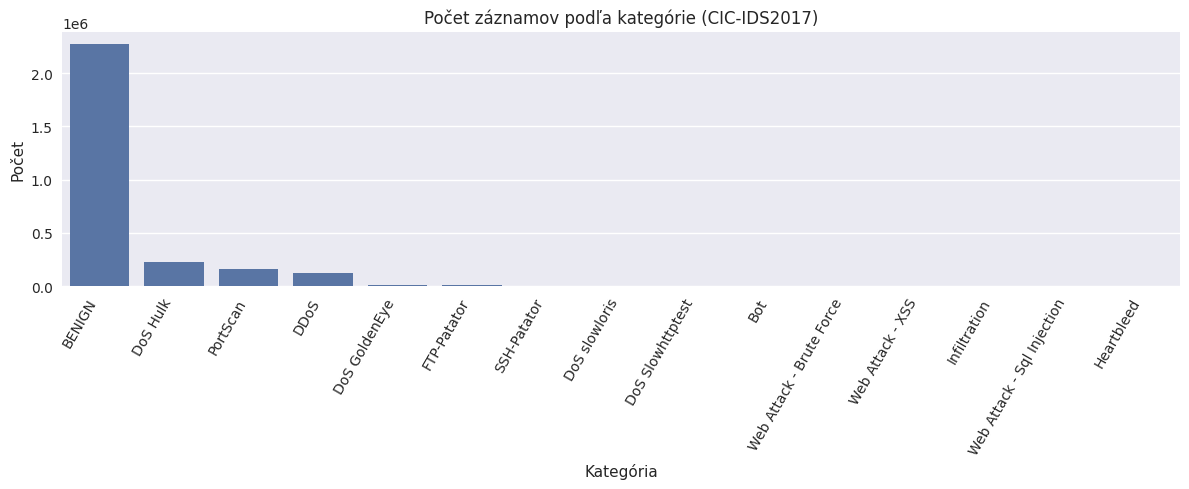

In [10]:
plt.figure(figsize=(12, 5))
sns.barplot(data=attack_counts, x="attack_cat", y="count")
plt.xticks(rotation=60, ha="right")
plt.title("Počet záznamov podľa kategórie (CIC-IDS2017)")
plt.xlabel("Kategória")
plt.ylabel("Počet")
plt.tight_layout()
plt.show()

In [11]:
source_counts = df["source_file"].value_counts().reset_index()
source_counts.columns = ["source_file", "count"]

source_counts

,source_file,count
0,Wednesday-workingHours.pcap_ISCX.csv,692703
1,Monday-WorkingHours.pcap_ISCX.csv,529918
2,Tuesday-WorkingHours.pcap_ISCX.csv,445909
3,Thursday-WorkingHours-Afternoon-Infilteration....,288602
4,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467
5,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745
6,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033
7,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,170366


In [12]:
label_by_source = (
    df.groupby(["source_file", label_col])
      .size()
      .reset_index(name="count")
      .sort_values(["source_file", "count"], ascending=[True, False])
)

label_by_source

,source_file,Label,count
1,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,DDoS,128027
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,BENIGN,97718
3,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,PortScan,158930
2,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,BENIGN,127537
4,Friday-WorkingHours-Morning.pcap_ISCX.csv,BENIGN,189067
5,Friday-WorkingHours-Morning.pcap_ISCX.csv,Bot,1966
6,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,529918
7,Thursday-WorkingHours-Afternoon-Infilteration....,BENIGN,288566
8,Thursday-WorkingHours-Afternoon-Infilteration....,Infiltration,36
9,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,BENIGN,168186


In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Počet numerických atribútov:", len(numeric_cols))
numeric_cols[:30]

Počet numerických atribútov: 79


['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min']

Shape pre koreláciu: (100000, 79)


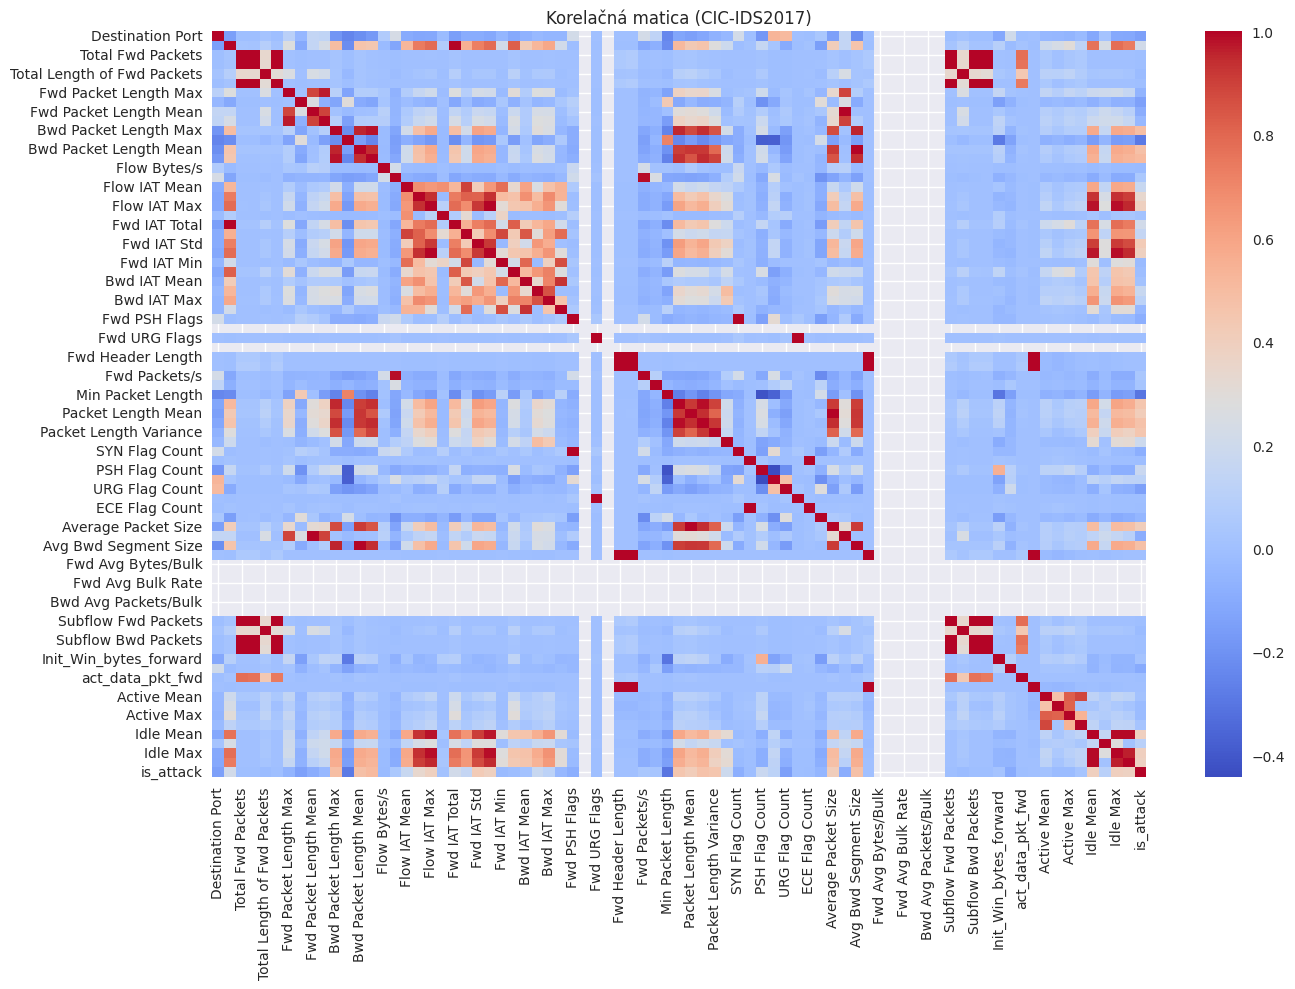

In [14]:
CORR_SAMPLE_SIZE = 100_000

df_corr = df[numeric_cols].replace([np.inf, -np.inf], np.nan).dropna()

if len(df_corr) > CORR_SAMPLE_SIZE:
    df_corr = df_corr.sample(n=CORR_SAMPLE_SIZE, random_state=42)

print("Shape pre koreláciu:", df_corr.shape)

plt.figure(figsize=(14, 10))
sns.heatmap(df_corr.corr(), cmap="coolwarm")
plt.title("Korelačná matica (CIC-IDS2017)")
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np

df_eda = df.copy()
df_eda.columns = df_eda.columns.str.strip()

label_col = "Label"

if label_col not in df_eda.columns:
    raise ValueError(f"Stĺpec '{label_col}' sa v datasete nenachádza. Skontroluj názov stĺpca s triedou.")

df_eda[label_col] = df_eda[label_col].astype(str).str.strip()

candidate_cols = [
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow Duration",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Fwd IAT Mean",
    "Bwd IAT Mean"
]

existing_cols = [col for col in candidate_cols if col in df_eda.columns]
missing_cols = [col for col in candidate_cols if col not in df_eda.columns]

print("Použité stĺpce:")
print(existing_cols)

print("\nChýbajúce stĺpce:")
print(missing_cols)

for col in existing_cols:
    df_eda[col] = pd.to_numeric(df_eda[col], errors="coerce")

df_eda[existing_cols] = df_eda[existing_cols].replace([np.inf, -np.inf], np.nan)

before = len(df_eda)
df_eda_clean = df_eda.dropna(subset=existing_cols + [label_col]).copy()
after = len(df_eda_clean)

print("\nPočet riadkov pred čistením:", before)
print("Počet riadkov po čistení:", after)
print("Odstránené riadky:", before - after)

print("\nPočet záznamov podľa tried:")
display(df_eda_clean[label_col].value_counts().to_frame("count"))

# =========================
# 1. Objemové atribúty
# =========================

volume_cols = [
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s"
]

volume_cols = [col for col in volume_cols if col in df_eda_clean.columns]

volume_profile = df_eda_clean.groupby(label_col)[volume_cols].agg(["mean", "median"])
volume_profile.columns = [f"{col}_{stat}" for col, stat in volume_profile.columns]
volume_profile = volume_profile.reset_index()

volume_profile_rounded = volume_profile.copy()

for col in volume_profile_rounded.columns:
    if col != label_col:
        volume_profile_rounded[col] = volume_profile_rounded[col].round(2)

print("\nŠtatistické profily objemových atribútov podľa kategórie útoku:")
display(volume_profile_rounded)

print("\nLaTeX tabuľka - objemové atribúty:")
print(
    volume_profile_rounded.to_latex(
        index=False,
        escape=False,
        caption="Štatistické profily objemových atribútov podľa kategórie útoku (CIC-IDS2017).",
        label="tab:cic-attack-profiles-volume"
    )
)

# =========================
# 2. Paketové a časové atribúty
# =========================

behaviour_cols = [
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Packets/s",
    "Flow Duration",
    "Flow IAT Mean"
]

behaviour_cols = [col for col in behaviour_cols if col in df_eda_clean.columns]

behaviour_profile = df_eda_clean.groupby(label_col)[behaviour_cols].agg(["mean", "median"])
behaviour_profile.columns = [f"{col}_{stat}" for col, stat in behaviour_profile.columns]
behaviour_profile = behaviour_profile.reset_index()

behaviour_profile_rounded = behaviour_profile.copy()

for col in behaviour_profile_rounded.columns:
    if col != label_col:
        behaviour_profile_rounded[col] = behaviour_profile_rounded[col].round(2)

print("\nŠtatistické profily paketových a časových atribútov podľa kategórie útoku:")
display(behaviour_profile_rounded)

print("\nLaTeX tabuľka - paketové a časové atribúty:")
print(
    behaviour_profile_rounded.to_latex(
        index=False,
        escape=False,
        caption="Štatistické profily paketových a časových atribútov podľa kategórie útoku (CIC-IDS2017).",
        label="tab:cic-attack-profiles-behaviour"
    )
)

Použité stĺpce:
['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow Bytes/s', 'Flow Packets/s', 'Flow Duration', 'Flow IAT Mean', 'Flow IAT Std', 'Fwd IAT Mean', 'Bwd IAT Mean']

Chýbajúce stĺpce:
[]

Počet riadkov pred čistením: 2830743
Počet riadkov po čistení: 2827876
Odstránené riadky: 2867

Počet záznamov podľa tried:


,count
Label,
BENIGN,2271320
DoS Hulk,230124
PortScan,158804
DDoS,128025
DoS GoldenEye,10293
FTP-Patator,7935
SSH-Patator,5897
DoS slowloris,5796
DoS Slowhttptest,5499



Štatistické profily objemových atribútov podľa kategórie útoku:


,Label,Total Length of Fwd Packets_mean,Total Length of Fwd Packets_median,Total Length of Bwd Packets_mean,Total Length of Bwd Packets_median,Flow Bytes/s_mean,Flow Bytes/s_median
0,BENIGN,636.03,66.0,18863.45,130.0,1779841.56,5149.77
1,Bot,2658.94,6.0,64.10,18.0,307099.15,5021.95
2,DDoS,31.91,26.0,7373.74,11601.0,61117.88,160.10
3,DoS GoldenEye,418.43,377.0,6561.32,4154.0,688.24,650.33
4,DoS Hulk,282.49,334.0,7802.76,11595.0,29401.72,121.17
5,DoS Slowhttptest,496.55,0.0,118.39,0.0,21642420.63,0.00
6,DoS slowloris,810.69,16.0,20.59,0.0,43921.22,2.23
7,FTP-Patator,60.05,31.0,93.94,76.0,799464.59,38.20
8,Heartbleed,12509.73,12264.0,7276360.64,7878135.0,65902.80,66172.23
9,Infiltration,376725.78,7020.0,5013.67,174.0,20188.22,173.35



LaTeX tabuľka - objemové atribúty:
\begin{table}
\caption{Štatistické profily objemových atribútov podľa kategórie útoku (CIC-IDS2017).}
\label{tab:cic-attack-profiles-volume}
\begin{tabular}{lrrrrrr}
\toprule
Label & Total Length of Fwd Packets_mean & Total Length of Fwd Packets_median & Total Length of Bwd Packets_mean & Total Length of Bwd Packets_median & Flow Bytes/s_mean & Flow Bytes/s_median \\
\midrule
BENIGN & 636.030000 & 66.000000 & 18863.450000 & 130.000000 & 1779841.560000 & 5149.770000 \\
Bot & 2658.940000 & 6.000000 & 64.100000 & 18.000000 & 307099.150000 & 5021.950000 \\
DDoS & 31.910000 & 26.000000 & 7373.740000 & 11601.000000 & 61117.880000 & 160.100000 \\
DoS GoldenEye & 418.430000 & 377.000000 & 6561.320000 & 4154.000000 & 688.240000 & 650.330000 \\
DoS Hulk & 282.490000 & 334.000000 & 7802.760000 & 11595.000000 & 29401.720000 & 121.170000 \\
DoS Slowhttptest & 496.550000 & 0.000000 & 118.390000 & 0.000000 & 21642420.630000 & 0.000000 \\
DoS slowloris & 810.690000 

,Label,Total Fwd Packets_mean,Total Fwd Packets_median,Total Backward Packets_mean,Total Backward Packets_median,Flow Packets/s_mean,Flow Packets/s_median,Flow Duration_mean,Flow Duration_median,Flow IAT Mean_mean,Flow IAT Mean_median
0,BENIGN,10.66,2.0,12.15,2.0,64778.59,122.53,1.122960e+07,31003.0,909559.38,10591.00
1,Bot,3.21,3.0,3.36,3.0,46841.28,101.34,3.527369e+05,70974.0,59677.91,11512.25
2,DDoS,4.47,4.0,3.26,4.0,172.79,2.59,1.695586e+07,1878984.0,1881553.67,489282.00
3,DoS GoldenEye,5.90,7.0,3.71,5.0,9.14,0.98,2.312722e+07,11588797.0,13824957.77,1132296.86
4,DoS Hulk,5.29,6.0,4.22,6.0,182511.92,0.16,5.731713e+07,84944326.0,4799159.23,6602750.03
5,DoS Slowhttptest,5.74,7.0,0.96,0.0,22235.78,0.11,5.771989e+07,63117636.0,9609412.45,10500000.00
6,DoS slowloris,6.34,3.0,1.66,2.0,4231.88,0.18,5.655437e+07,97082009.0,10207273.01,5869120.42
7,FTP-Patator,5.50,6.0,7.81,6.0,115888.89,3.20,4.514951e+06,4056257.0,196890.20,326206.61
8,Heartbleed,2583.73,2792.0,1897.18,2069.0,40.56,40.84,1.106797e+08,119261118.0,24684.47,24493.53
9,Infiltration,830.22,26.0,829.61,26.0,2820.06,1.00,7.840772e+07,93188869.0,2020438.93,1016159.19



LaTeX tabuľka - paketové a časové atribúty:
\begin{table}
\caption{Štatistické profily paketových a časových atribútov podľa kategórie útoku (CIC-IDS2017).}
\label{tab:cic-attack-profiles-behaviour}
\begin{tabular}{lrrrrrrrrrr}
\toprule
Label & Total Fwd Packets_mean & Total Fwd Packets_median & Total Backward Packets_mean & Total Backward Packets_median & Flow Packets/s_mean & Flow Packets/s_median & Flow Duration_mean & Flow Duration_median & Flow IAT Mean_mean & Flow IAT Mean_median \\
\midrule
BENIGN & 10.660000 & 2.000000 & 12.150000 & 2.000000 & 64778.590000 & 122.530000 & 11229599.540000 & 31003.000000 & 909559.380000 & 10591.000000 \\
Bot & 3.210000 & 3.000000 & 3.360000 & 3.000000 & 46841.280000 & 101.340000 & 352736.860000 & 70974.000000 & 59677.910000 & 11512.250000 \\
DDoS & 4.470000 & 4.000000 & 3.260000 & 4.000000 & 172.790000 & 2.590000 & 16955856.650000 & 1878984.000000 & 1881553.670000 & 489282.000000 \\
DoS GoldenEye & 5.900000 & 7.000000 & 3.710000 & 5.000000 & 9.14

In [16]:
df.to_csv(OUTPUT_MERGED, index=False)
print("Merged dataset uložený ako:", OUTPUT_MERGED)

Merged dataset uložený ako: data\CIC_IDS2017_merged.csv


In [17]:
SAMPLE_FRAC = 0.2
MIN_PER_GROUP = 100
RANDOM_STATE = 42

In [18]:
def sample_group(group):
    n = len(group)

    if n <= MIN_PER_GROUP:
        return group

    sample_n = int(n * SAMPLE_FRAC)
    sample_n = max(sample_n, MIN_PER_GROUP)
    sample_n = min(sample_n, n)

    return group.sample(n=sample_n, random_state=RANDOM_STATE)

df_sampled = (
    df.groupby([label_col, "source_file"], group_keys=False)
      .apply(sample_group)
      .reset_index(drop=True)
)

print("Original shape:", df.shape)
print("Sampled shape:", df_sampled.shape)

C:\Users\Denis\AppData\Local\Temp\ipykernel_24332\1535273615.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sample_group)


Original shape: (2830743, 81)
Sampled shape: (566195, 81)


In [19]:
original_dist = df[label_col].value_counts().reset_index()
original_dist.columns = ["attack_cat", "original_count"]

sampled_dist = df_sampled[label_col].value_counts().reset_index()
sampled_dist.columns = ["attack_cat", "sampled_count"]

dist_compare = original_dist.merge(sampled_dist, on="attack_cat", how="left")
dist_compare["sampled_count"] = dist_compare["sampled_count"].fillna(0).astype(int)
dist_compare["sampled_percent_of_original"] = (
    dist_compare["sampled_count"] / dist_compare["original_count"] * 100
)

dist_compare

,attack_cat,original_count,sampled_count,sampled_percent_of_original
0,BENIGN,2273097,454616,19.999850
1,DoS Hulk,231073,46214,19.999740
2,PortScan,158930,31786,20.000000
3,DDoS,128027,25605,19.999688
4,DoS GoldenEye,10293,2058,19.994171
5,FTP-Patator,7938,1587,19.992441
6,SSH-Patator,5897,1179,19.993217
7,DoS slowloris,5796,1159,19.996549
8,DoS Slowhttptest,5499,1099,19.985452
9,Bot,1966,393,19.989827


In [20]:
original_source_dist = df["source_file"].value_counts().reset_index()
original_source_dist.columns = ["source_file", "original_count"]

sampled_source_dist = df_sampled["source_file"].value_counts().reset_index()
sampled_source_dist.columns = ["source_file", "sampled_count"]

source_compare = original_source_dist.merge(sampled_source_dist, on="source_file", how="left")
source_compare["sampled_count"] = source_compare["sampled_count"].fillna(0).astype(int)
source_compare["sampled_percent_of_original"] = (
    source_compare["sampled_count"] / source_compare["original_count"] * 100
)

source_compare

,source_file,original_count,sampled_count,sampled_percent_of_original
0,Wednesday-workingHours.pcap_ISCX.csv,692703,138547,20.000924
1,Monday-WorkingHours.pcap_ISCX.csv,529918,105983,19.999887
2,Tuesday-WorkingHours.pcap_ISCX.csv,445909,89180,19.999596
3,Thursday-WorkingHours-Afternoon-Infilteration....,288602,57749,20.009910
4,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467,57293,19.999860
5,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,45148,19.999557
6,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,38206,19.999686
7,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,170366,34089,20.009274


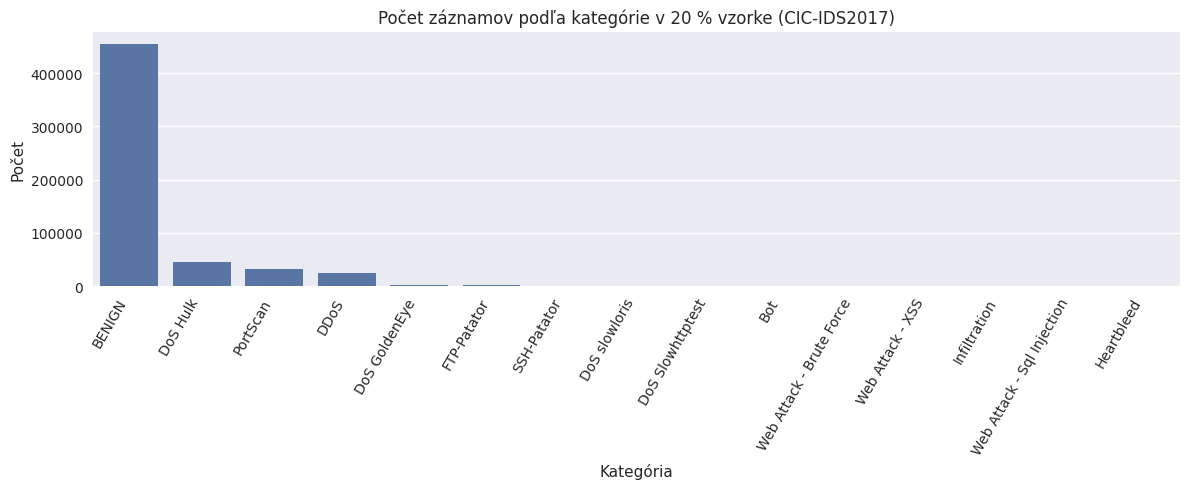

In [21]:
sampled_counts = df_sampled[label_col].value_counts().reset_index()
sampled_counts.columns = ["attack_cat", "count"]
sampled_counts["percent"] = sampled_counts["count"] / sampled_counts["count"].sum() * 100

plt.figure(figsize=(12, 5))
sns.barplot(data=sampled_counts, x="attack_cat", y="count")
plt.xticks(rotation=60, ha="right")
plt.title("Počet záznamov podľa kategórie v 20 % vzorke (CIC-IDS2017)")
plt.xlabel("Kategória")
plt.ylabel("Počet")
plt.tight_layout()
plt.show()

In [22]:
df_sampled.to_csv(OUTPUT_SAMPLED, index=False)
print("Sampled dataset uložený ako:", OUTPUT_SAMPLED)

Sampled dataset uložený ako: data\CIC_IDS2017_sampled.csv


In [23]:
print("Používaj tento súbor vo všetkých CIC modeloch:")
print(OUTPUT_SAMPLED)

print("\nBinárne rozdelenie v sampled datasete:")
print((df_sampled[label_col] != "BENIGN").astype(int).value_counts())

print("\nDistribúcia tried v sampled datasete:")
print(df_sampled[label_col].value_counts())

print("\nShape sampled datasetu:")
print(df_sampled.shape)

Používaj tento súbor vo všetkých CIC modeloch:
data\CIC_IDS2017_sampled.csv

Binárne rozdelenie v sampled datasete:
Label
0    454616
1    111579
Name: count, dtype: int64

Distribúcia tried v sampled datasete:
Label
BENIGN                        454616
DoS Hulk                       46214
PortScan                       31786
DDoS                           25605
DoS GoldenEye                   2058
FTP-Patator                     1587
SSH-Patator                     1179
DoS slowloris                   1159
DoS Slowhttptest                1099
Bot                              393
Web Attack - Brute Force         301
Web Attack - XSS                 130
Infiltration                      36
Web Attack - Sql Injection        21
Heartbleed                        11
Name: count, dtype: int64

Shape sampled datasetu:
(566195, 81)
